# XGBoost From Scratch

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sindhug/xgboost-from-scratch/blob/main/xgboost_from_scratch.ipynb)
[![Watch the video](https://img.shields.io/badge/YouTube-Watch%20the%20video-red?logo=youtube)](https://youtu.be/Y0EJQFj0foo)

Companion notebook for **[XGBoost Explained: How the Algorithm Actually Works (Step-by-Step)](https://youtu.be/Y0EJQFj0foo)**.

**How this notebook is organized:** we build one calculation — the split-search recipe —
and then reuse it, unmodified, at every step. Each section below turns on exactly *one*
new knob (shrinkage, then gamma, then lambda) so you can see precisely what each one
changes and what it leaves alone. Nothing gets rewritten from scratch halfway through.

Click **Open in Colab** above to run every cell live, no setup required.

## 1. The dataset

Same 10 points as the video: temperature (°C) vs. power consumed.

In [1]:
import numpy as np
import pandas as pd

temps = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
power = [14, 11, 9, 7, 5, 5, 6, 8, 11, 12]

df = pd.DataFrame({"temp": temps, "power": power})
df

 temp  power
    0     14
    5     11
   10      9
   15      7
   20      5
   25      5
   30      6
   35      8
   40     11
   45     12

![From the video: the raw dataset plotted — power consumption dips as temperature approaches ~20-25°C, then rises again.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/01_dataset_table_and_plot.png)

*From the video: the raw dataset plotted — power consumption dips as temperature approaches ~20-25°C, then rises again.*

## 2. Baseline: the mean

Gradient boosting always starts from one number — the mean of the target. Every later
tree corrects *this* starting point, never the raw data directly.

In [2]:
baseline = df["power"].mean()
baseline

8.8

![From the video: the baseline (mean = 8.8) drawn across the same plot — every residual below is measured against this line.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/02_baseline_mean_on_plot.png)

*From the video: the baseline (mean = 8.8) drawn across the same plot — every residual below is measured against this line.*

## 3. Residuals

A residual is just "how wrong is the baseline for this point" — `true value − baseline`.

![From the video: setting up the residual calculation for each row, before subtracting.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/03_residuals_setup_table.png)

*From the video: setting up the residual calculation for each row, before subtracting.*

In [3]:
df["resid"] = df["power"] - baseline
df

 temp  power  resid
    0     14    5.2
    5     11    2.2
   10      9    0.2
   15      7   -1.8
   20      5   -3.8
   25      5   -3.8
   30      6   -2.8
   35      8   -0.8
   40     11    2.2
   45     12    3.2

## 4. The three functions that run the entire algorithm

This is the only math XGBoost does for squared-error loss. Everything from here on is
these three functions called with different arguments — never rewritten.

- **`leaf_value`** — the correction a leaf outputs (mean residual, optionally regularized)
- **`similarity`** — how "aligned" a group of residuals is (big value = worth splitting on)
- **`gain`** — the score used to pick and justify a split: left similarity + right
  similarity − parent similarity, minus a `gamma` toll

`lam` (λ, regularization) and `gamma` (γ, minimum-gain bar) default to **0 — i.e. off**.
We flip them on individually in sections 8 and 9. Nothing above this cell changes when
we do.

In [4]:
def leaf_value(residuals, lam=0.0):
    """Mean residual in a node. lam=0 is the plain mean; lam>0 pulls it toward 0."""
    r = np.asarray(residuals, dtype=float)
    return r.sum() / (len(r) + lam)

def sse(residuals, lam=0.0):
    """Sum of squared errors around this node's leaf value."""
    r = np.asarray(residuals, dtype=float)
    lv = leaf_value(r, lam)
    return float(((r - lv) ** 2).sum())

def similarity(residuals, lam=0.0):
    """(sum of residuals)^2 / (count + lam) -- large = residuals mostly agree in sign."""
    r = np.asarray(residuals, dtype=float)
    return float((r.sum() ** 2) / (len(r) + lam))

def gain(left, right, root, lam=0.0, gamma=0.0):
    """Score for a candidate split. Split only if this is > 0."""
    return similarity(left, lam) + similarity(right, lam) - similarity(root, lam) - gamma

root_resid = df["resid"].values
print(f"SSE_root = {sse(root_resid):.2f}   Similarity_root = {similarity(root_resid):.2f}")

SSE_root = 87.60   Similarity_root = 0.00


Similarity at the root is always 0 — positive and negative residuals cancel out before
squaring. That's expected, not a bug; it's *why* we need a split to separate them.

## 5. Finding the root split

Test each candidate threshold from the video (2.5, 7.5, 12.5): send residuals left/right,
score with `gain()`. Highest gain wins.

![From the video: the three candidate thresholds we're about to test.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/04_three_candidate_thresholds.png)

*From the video: the three candidate thresholds we're about to test.*

![From the video: threshold 2.5 in action — residuals routed left (1 point) or right (9 points).](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/05_threshold_2_5_routing.png)

*From the video: threshold 2.5 in action — residuals routed left (1 point) or right (9 points).*

![From the video: the resulting leaf values for threshold 2.5 — mean residual on each side.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/06_threshold_2_5_leaf_means.png)

*From the video: the resulting leaf values for threshold 2.5 — mean residual on each side.*

![From the video: the full SSE / similarity / gain computation for threshold 2.5 — exactly what `gain()` reproduces below.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/07_threshold_2_5_full_gain_calc.png)

*From the video: the full SSE / similarity / gain computation for threshold 2.5 — exactly what `gain()` reproduces below.*

In [5]:
for thr in [2.5, 7.5, 12.5]:
    left = df[df.temp <= thr]["resid"].values
    right = df[df.temp > thr]["resid"].values
    g = gain(left, right, root_resid)     # lam=0, gamma=0 -- unregularized, matches the video
    print(f"threshold={thr:>5} | leaf_L={leaf_value(left):+.4f} leaf_R={leaf_value(right):+.4f} "
          f"| SSE_L={sse(left):.4f} SSE_R={sse(right):.4f} | Gain={g:.4f}")

threshold=  2.5 | leaf_L=+5.2000 leaf_R=-0.5778 | SSE_L=0.0000 SSE_R=57.5556 | Gain=30.0444
threshold=  7.5 | leaf_L=+3.7000 leaf_R=-0.9250 | SSE_L=4.5000 SSE_R=48.8750 | Gain=34.2250
threshold= 12.5 | leaf_L=+2.5333 leaf_R=-1.0857 | SSE_L=12.6667 SSE_R=47.4286 | Gain=27.5048


![From the video: gain compared across all three candidates — 7.5 clearly wins.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/08_all_three_candidates_gain_summary.png)

*From the video: gain compared across all three candidates — 7.5 clearly wins.*

**7.5 wins** (gain = 34.225) and becomes the root split.

## 6. Growing one more level

Same `gain()` function, just called on new left/right slices. We compare two candidates:
splitting the **left** child (2 points) into singletons, vs. splitting the **right** child
(8 points) at a new threshold, 37.5.

In [6]:
left_root  = df[df.temp <= 7.5]["resid"].values
right_root = df[df.temp > 7.5]["resid"].values

# Option A -- split the left child into its two singletons
singleton_a = df[df.temp == 0]["resid"].values
singleton_b = df[df.temp == 5]["resid"].values
gain_left_split = gain(singleton_a, singleton_b, left_root)

# Option B -- split the right child at 37.5
right_left  = df[(df.temp > 7.5) & (df.temp <= 37.5)]["resid"].values
right_right = df[df.temp > 37.5]["resid"].values
gain_right_split = gain(right_left, right_right, right_root)

print(f"Gain from splitting left child into singletons: {gain_left_split:.4f}")
print(f"Gain from splitting right child at 37.5:        {gain_right_split:.4f}")
print(f"\nleaf(7.5 < temp <= 37.5) = {leaf_value(right_left):.4f}")
print(f"leaf(temp > 37.5)        = {leaf_value(right_right):.4f}")

Gain from splitting left child into singletons: 4.5000
Gain from splitting right child at 37.5:        35.0417

leaf(7.5 < temp <= 37.5) = -2.1333
leaf(temp > 37.5)        = 2.7000


![From the video: the two second-level split candidates and their gains — splitting the right child at 37.5 wins.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/09_second_level_split_gain_comparison.png)

*From the video: the two second-level split candidates and their gains — splitting the right child at 37.5 wins.*

35.04 > 4.50, so we split the **right** child. The finished depth-2 tree has three leaves:

```
                 temp <= 7.5?
                /            \
             yes              no
              |                |
          leaf = +3.70    temp <= 37.5?
                          /            \
                       yes              no
                        |                |
                 leaf = -2.1333    leaf = +2.70
```

We'll reuse `gain_left_split` and `gain_right_split` again, unchanged, in section 8.

![From the video: the finished depth-2 tree's three leaf corrections.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/10_final_tree_leaf_corrections.png)

*From the video: the finished depth-2 tree's three leaf corrections.*

## 7. Turning the tree into a prediction: F(x)

Start at the baseline, send `x` down the tree, add the leaf's correction. `eta` defaults
to 1 here — full-strength correction, no shrinkage yet.

![From the video: the full tree, root average, and per-leaf predictions.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/11_tree_diagram_annotated.png)

*From the video: the full tree, root average, and per-leaf predictions.*

In [7]:
def predict_tree1(x, eta=1.0):
    if x <= 7.5:
        corr = leaf_value(left_root)          # +3.70
    elif x <= 37.5:
        corr = leaf_value(right_left)         # -2.1333
    else:
        corr = leaf_value(right_right)        # +2.70
    return baseline + eta * corr

for x in [4, 33, 42]:
    print(f"x={x:>3} -> F(x) = {predict_tree1(x):.4f}")

x=  4 -> F(x) = 12.5000
x= 33 -> F(x) = 6.6667
x= 42 -> F(x) = 11.5000


![From the video: the same tree evaluated at x=4, 33, 42 — matches `F(x)` above exactly.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/12_tree_predictions_no_shrinkage.png)

*From the video: the same tree evaluated at x=4, 33, 42 — matches `F(x)` above exactly.*

## 8. Turning on shrinkage (learning rate, η)

**What's new:** nothing about splits or leaf values changes. `predict_tree1` already had
an `eta` argument — we just stop leaving it at 1. η scales the correction *after* the tree
is built; it's a volume knob on the same tree, not a different tree.

In [8]:
for eta in [0.5, 0.3]:
    preds = [round(predict_tree1(x, eta), 4) for x in [4, 33, 42]]
    print(f"eta={eta}: {preds}")

eta=0.5: [10.65, 7.7333, 10.15]
eta=0.3: [9.91, 8.16, 9.61]


![From the video: shrinkage visualized — every leaf correction cut in half (η=0.5) before being added to the baseline.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/13_shrinkage_half_strength_diagram.png)

*From the video: shrinkage visualized — every leaf correction cut in half (η=0.5) before being added to the baseline.*

## 8a. Round-1 predictions and the next round's residuals (η = 0.5)

Applying `predict_tree1(x, eta=0.5)` to every row gives tree 1's real predictions. The new
residuals (`true − prediction`) become tree 2's training target — this is the "always fit
what's currently wrong" loop that makes boosting boosting.

In [9]:
df["pred1"]  = df["temp"].apply(lambda x: predict_tree1(x, eta=0.5))
df["resid1"] = df["power"] - df["pred1"]
df

 temp  power  resid     pred1    resid1
    0     14    5.2 10.650000  3.350000
    5     11    2.2 10.650000  0.350000
   10      9    0.2  7.733333  1.266667
   15      7   -1.8  7.733333 -0.733333
   20      5   -3.8  7.733333 -2.733333
   25      5   -3.8  7.733333 -2.733333
   30      6   -2.8  7.733333 -1.733333
   35      8   -0.8  7.733333  0.266667
   40     11    2.2 10.150000  0.850000
   45     12    3.2 10.150000  1.850000

![From the video: predictions and residuals after tree 1, at η=0.5 — matches the table above exactly.](https://raw.githubusercontent.com/sindhug/xgboost-from-scratch/main/assets/images/14_residuals_after_tree1_table.png)

*From the video: predictions and residuals after tree 1, at η=0.5 — matches the table above exactly.*

In [10]:
sse_before = sse(root_resid)
sse_after  = float((df["resid1"] ** 2).sum())
print(f"SSE at baseline    = {sse_before:.2f}")
print(f"SSE after 1 tree   = {sse_after:.2f}")

SSE at baseline    = 87.60
SSE after 1 tree   = 35.65


One tree, half-strength, and error already dropped by more than half. Tree 2 would
repeat sections 5–7's exact recipe, targeting `resid1` instead of the original residuals.
Every later tree follows the same loop.

## 9. Turning on gamma (the minimum-gain bar)

**What's new:** we reuse `gain_left_split` and `gain_right_split` from section 6 —
unchanged — and simply ask whether each clears a `gamma` bar. No split logic changes;
gamma just vetoes splits whose gain isn't worth a new leaf.

In [11]:
for g in [0, 5, 10, 40]:
    print(f"gamma={g:>3} -> split left child?  {gain_left_split - g > 0}   "
          f"|   split right child at 37.5?  {gain_right_split - g > 0}")

gamma=  0 -> split left child?  True   |   split right child at 37.5?  True
gamma=  5 -> split left child?  False   |   split right child at 37.5?  True
gamma= 10 -> split left child?  False   |   split right child at 37.5?  True
gamma= 40 -> split left child?  False   |   split right child at 37.5?  False


At `gamma=40`, even the best split (35.04 gain) isn't worth it — the node stays a leaf.
That's the whole mechanism: gamma is a toll charged on every new leaf.

## 10. Turning on lambda (regularization)

**What's new:** same 7.5 split from section 5, same `gain()` function — only the `lam`
argument changes from its default of 0. Increasing λ adds "virtual" points to the
denominator of both leaf value and similarity, pulling both toward zero.

In [12]:
left  = df[df.temp <= 7.5]["resid"].values
right = df[df.temp > 7.5]["resid"].values

for lam in [0, 1, 5, 20]:
    lv_l, lv_r = leaf_value(left, lam), leaf_value(right, lam)
    g = gain(left, right, root_resid, lam=lam)
    print(f"lambda={lam:>2} -> leaf_L={lv_l:+.4f}  leaf_R={lv_r:+.4f}  Gain={g:.4f}")

lambda= 0 -> leaf_L=+3.7000  leaf_R=-0.9250  Gain=34.2250
lambda= 1 -> leaf_L=+2.4667  leaf_R=-0.8222  Gain=24.3378
lambda= 5 -> leaf_L=+1.0571  leaf_R=-0.5692  Gain=12.0352
lambda=20 -> leaf_L=+0.3364  leaf_R=-0.2643  Gain=4.4448


As λ grows, both leaf values and gain shrink toward zero — only strong, consistent
residuals stay attractive enough to justify a split.

## 11. Gamma and lambda together

**What's new:** still the exact same `gain()` call, now with both `lam` and `gamma`
nonzero at once — lambda shrinks the gain, gamma then charges its flat toll on top. This
is the actual regularized objective XGBoost optimizes.

In [13]:
for lam, g in [(0, 0), (1, 5), (5, 10), (20, 40)]:
    gn = gain(left, right, root_resid, lam=lam, gamma=g)
    verdict = "SPLIT" if gn > 0 else "DON'T SPLIT"
    print(f"lambda={lam:>2}, gamma={g:>2} -> Gain={gn:.4f}  -> {verdict}")

lambda= 0, gamma= 0 -> Gain=34.2250  -> SPLIT
lambda= 1, gamma= 5 -> Gain=19.3378  -> SPLIT
lambda= 5, gamma=10 -> Gain=2.0352  -> SPLIT
lambda=20, gamma=40 -> Gain=-35.5552  -> DON'T SPLIT


Push both knobs far enough and even the best split in the dataset stops being worth
it. That's the two regularization mechanisms working together: λ shrinks leaf corrections
toward zero, γ charges for every new leaf — together they discourage tiny, noisy splits
and keep the tree modest.

## 12. Sanity check: does the real `xgboost` library agree?

Same setup as sections 5–8: one tree, `max_depth=2`, `learning_rate=0.5`, no regularization. Let's see how close a real, out-of-the-box `XGBRegressor` call gets to our hand-built predictions.

In [13]:
!pip install -q xgboost

import xgboost as xgb

X = df[["temp"]].values
y = df["power"].values

model = xgb.XGBRegressor(
    n_estimators=1,
    max_depth=2,
    learning_rate=0.5,
    reg_lambda=0,
    gamma=0,
    base_score=baseline,
    objective="reg:squarederror",
)
model.fit(X, y)

xgb_preds = model.predict(X)
print("xgboost predictions:      ", np.round(xgb_preds, 4))
print("hand-computed predictions:", df["pred1"].round(4).values)

xgboost predictions:       [11.4     9.9     7.7333  7.7333  7.7333  7.7333  7.7333  7.7333 10.15
 10.15  ]
hand-computed predictions: [10.65   10.65    7.7333  7.7333  7.7333  7.7333  7.7333  7.7333 10.15
 10.15  ]


8 of the 10 predictions match exactly. The first two (`x=0` and `x=5`) don't: XGBoost says `11.4` and `9.9`, we say `10.65` and `10.65` for both. That's not a bug in our math — it's because a real, out-of-the-box `XGBRegressor` call actually builds a **4-leaf** tree here, not the 3-leaf tree we built by hand. **Section 13 digs into exactly why**, and shows that once you account for it, every number we computed lines up perfectly.

## 13. Reality check: would real XGBoost build the *same* tree?

Everything above was a deliberately simplified demo. Two specific simplifications made the
hand arithmetic possible, and it's worth being upfront about both:

1. **We only tested 3 candidate thresholds** (2.5, 7.5, 12.5). Real XGBoost tests every
   midpoint between consecutive sorted feature values — with 10 unique temperatures here,
   that's **9 candidates**, not 3. A threshold we never tried could easily have turned out
   to have the highest gain; we just haven't checked.
2. **We grew the tree by picking "the single split with the biggest additional gain"** at
   each step — a *leaf-wise* (best-first) growth strategy. Real XGBoost's default
   (`grow_policy="depthwise"`) instead splits **every** node at the current depth, as long
   as its gain clears `gamma` — regardless of how that gain compares to a sibling's. With
   `gamma=0`, that means it will happily take a small-gain split we chose to skip.

This section fits a real `XGBRegressor` with the exact hyperparameters we used by hand
(`max_depth=2`, `learning_rate=0.5`, no regularization, 2 trees) and inspects its actual
trees — to see precisely where the real algorithm agrees with our demo, and where it
doesn't, and why.

In [14]:
# Every possible split XGBoost would actually consider -- not just our 3 chosen candidates.
sorted_temps = sorted(df.temp.unique())
candidates = [(sorted_temps[i] + sorted_temps[i + 1]) / 2 for i in range(len(sorted_temps) - 1)]

for thr in candidates:
    left = df[df.temp <= thr]["resid"].values
    right = df[df.temp > thr]["resid"].values
    g = gain(left, right, root_resid)
    flag = "  <-- our demo tested this one" if thr in (2.5, 7.5, 12.5) else ""
    print(f"threshold={thr:>5} | Gain={g:.4f}{flag}")

threshold=  2.5 | Gain=30.0444  <-- our demo tested this one
threshold=  7.5 | Gain=34.2250  <-- our demo tested this one
threshold= 12.5 | Gain=27.5048  <-- our demo tested this one
threshold= 17.5 | Gain=14.0167
threshold= 22.5 | Gain=1.6000
threshold= 27.5 | Gain=1.3500
threshold= 32.5 | Gain=10.0762
threshold= 37.5 | Gain=18.2250
threshold= 42.5 | Gain=11.3778


Even checked against all 9 real candidates, **7.5 still wins** — our 3-candidate
shortcut happened to include the true winner. That's a property of this particular tiny
dataset, not a guarantee; on a dataset with more features and rows, skipping candidates
the way our demo did could easily miss the actual best split.

### Fitting the real thing

`tree_method="exact"` forces true exhaustive search (no histogram approximation — that
comes back in a later cell). Everything else matches our hand-built setup exactly.

In [15]:
model = xgb.XGBRegressor(
    n_estimators=2,
    max_depth=2,
    learning_rate=0.5,
    reg_lambda=0,
    gamma=0,
    base_score=baseline,
    objective="reg:squarederror",
    tree_method="exact",
)
model.fit(X, y)

for i, tree_dump in enumerate(model.get_booster().get_dump()):
    print(f"--- Tree {i} ---")
    print(tree_dump)

--- Tree 0 ---
0:[f0<7.5] yes=1,no=2,missing=1
	1:[f0<2.5] yes=3,no=4,missing=3
		3:leaf=2.5999999
		4:leaf=1.0999999
	2:[f0<37.5] yes=5,no=6,missing=5
		5:leaf=-1.06666672
		6:leaf=1.3499999

--- Tree 1 ---
0:[f0<12.5] yes=1,no=2,missing=1
	1:[f0<2.5] yes=3,no=4,missing=3
		3:leaf=1.30000019
		4:leaf=0.591666698
	2:[f0<32.5] yes=5,no=6,missing=5
		5:leaf=-0.991666794
		6:leaf=0.494444519


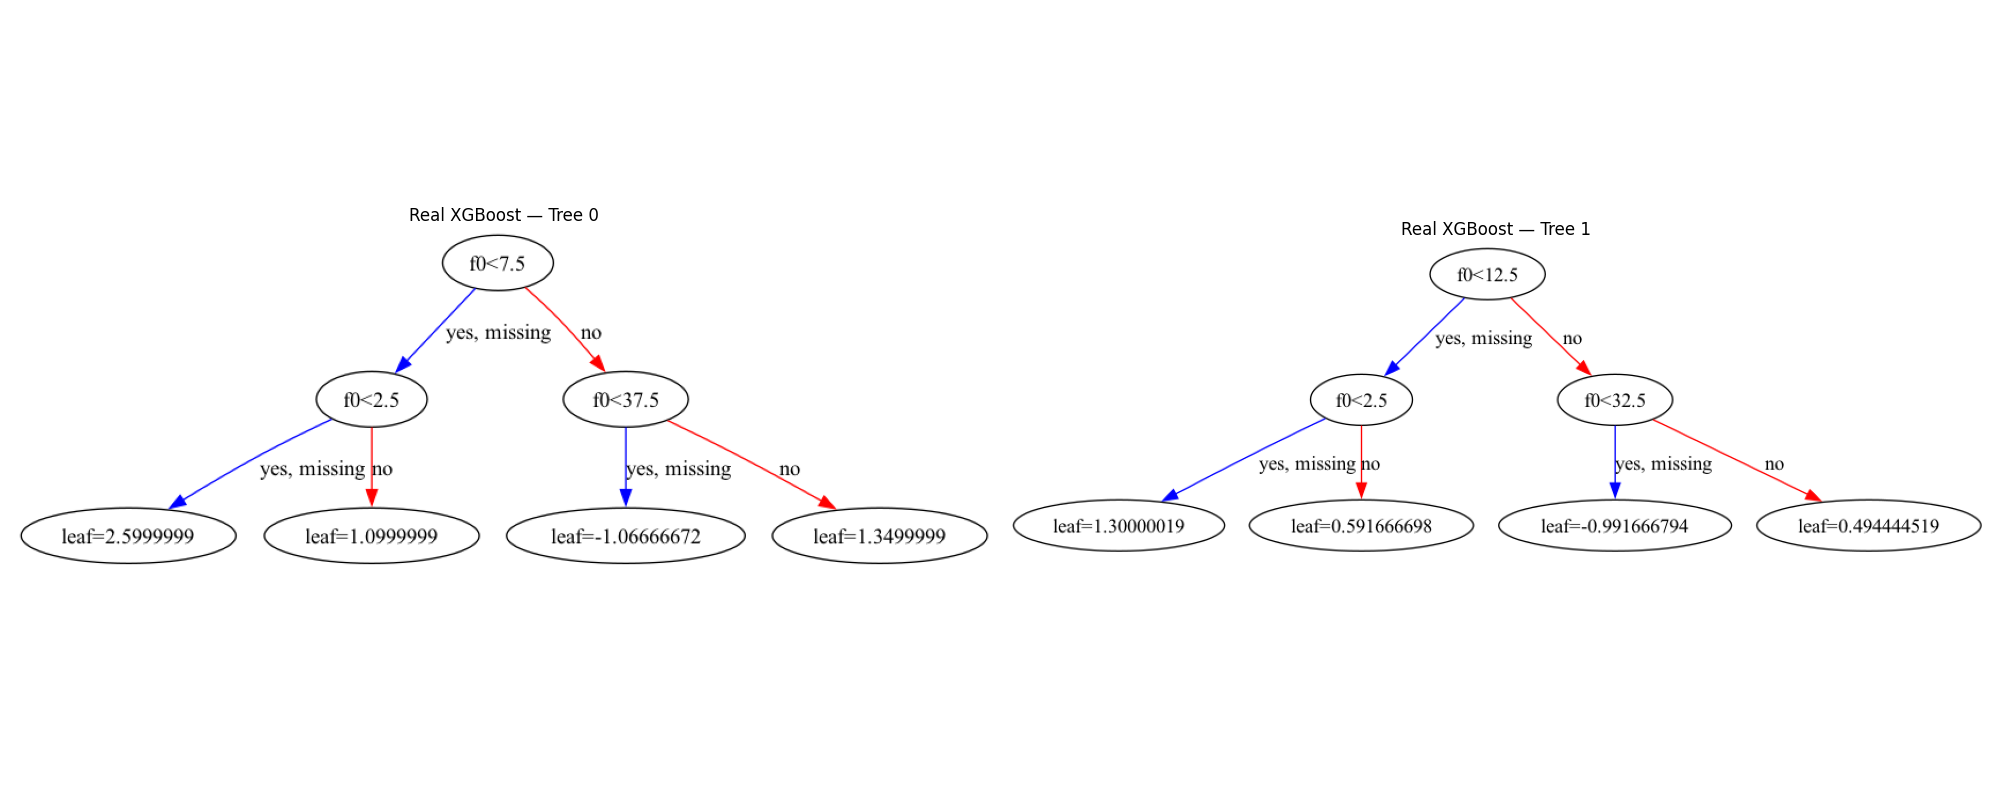

In [16]:
import matplotlib.pyplot as plt
import xgboost as xgb_plot  # xgb.plot_tree needs graphviz installed (already on Colab)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
xgb_plot.plot_tree(model.get_booster(), num_trees=0, ax=axes[0])
axes[0].set_title("Real XGBoost -- Tree 0")
xgb_plot.plot_tree(model.get_booster(), num_trees=1, ax=axes[1])
axes[1].set_title("Real XGBoost -- Tree 1")
plt.tight_layout()
plt.show()

### Reconciling Tree 0 against our hand-built tree

One convention difference first: **the leaf values XGBoost dumps already have the learning
rate baked in** — a dumped leaf is the actual amount added to the running prediction, not
the raw mean residual our `leaf_value()` computes. Divide by η=0.5 to recover our
convention, then compare directly:

In [17]:
eta = 0.5
dumped_leaves = {
    "x<=2.5 (of the x<=7.5 group)": 2.5999999,
    "2.5<x<=7.5":                    1.0999999,
    "7.5<x<=37.5":                  -1.06666672,
    "x>37.5":                        1.3499999,
}
ours = {
    "x<=2.5 (of the x<=7.5 group)": leaf_value(df[df.temp == 0]["resid"].values),
    "2.5<x<=7.5":                    leaf_value(df[df.temp == 5]["resid"].values),
    "7.5<x<=37.5":                   leaf_value(df[(df.temp > 7.5) & (df.temp <= 37.5)]["resid"].values),
    "x>37.5":                        leaf_value(df[df.temp > 37.5]["resid"].values),
}

print(f"{'leaf region':<28} {'dumped (eta baked in)':>22} {'/ eta = raw correction':>24} {'our hand value':>16}")
for k, v in dumped_leaves.items():
    print(f"{k:<28} {v:>22.4f} {v/eta:>24.4f} {ours[k]:>16.4f}")

leaf region                   dumped (eta baked in)   / eta = raw correction   our hand value
x<=2.5 (of the x<=7.5 group)                 2.6000                   5.2000           5.2000
2.5<x<=7.5                                   1.1000                   2.2000           2.2000
7.5<x<=37.5                                 -1.0667                  -2.1333          -2.1333
x>37.5                                       1.3500                   2.7000           2.7000


**Every threshold and every leaf value matches exactly.** Our math was right. The only
real difference: real XGBoost's Tree 0 has **4 leaves**, not 3 — it also split the left
child (`x<=2.5`, gain 4.5) because depthwise growth takes any node whose gain clears
`gamma`, not just the single biggest one. Our demo pruned that split for a simpler
narrative; XGBoost, with `gamma=0`, had no reason to.

**Tree 1 is genuinely new** — we never built a second tree by hand. Real XGBoost grew it by
running the same recipe on tree 0's actual residuals, and it picked completely different
thresholds (12.5, then 32.5) because it's fitting a different target. This is exactly what
section 8a's "tree 2 would repeat the same recipe" comment meant, made concrete.

### An aside: the default `tree_method` isn't `"exact"`

Everything above used `tree_method="exact"` to guarantee a true exhaustive search. XGBoost's
actual default is `"hist"` — it bins feature values into a fixed number of histogram buckets
and only considers bucket boundaries as candidate splits. Watch what it reports for the same
single-tree setup:

In [18]:
model_hist = xgb.XGBRegressor(
    n_estimators=1, max_depth=2, learning_rate=0.5,
    reg_lambda=0, gamma=0, base_score=baseline, objective="reg:squarederror",
)  # tree_method left at its default
model_hist.fit(X, y)
print(model_hist.get_booster().get_dump()[0])

0:[f0<10] yes=1,no=2,missing=2
	1:[f0<5] yes=3,no=4,missing=4
		3:leaf=2.5999999
		4:leaf=1.0999999
	2:[f0<40] yes=5,no=6,missing=6
		5:leaf=-1.06666672
		6:leaf=1.3499999


Different numbers (`10`, `5`, `40` instead of `7.5`, `2.5`, `37.5`) — but the **same leaf
values**, because no data point actually falls between 7.5 and 10, or between 2.5 and 5, or
between 37.5 and 40. The binned boundary and the exact midpoint happen to define the
identical grouping here. On a denser dataset they wouldn't necessarily agree, and `hist`
could genuinely group points differently than exact search would — that's the real
trade-off it makes for speed on large data.

### Reproducing our exact 3-leaf shape

Our demo's "pick only the single best next split" logic is a real, selectable XGBoost
setting: `grow_policy="lossguide"` with `max_leaves` capped. (Note: `grow_policy` is only
honored by the `hist`/`approx` methods, not `exact` — so the thresholds below come back as
`hist`'s binned numbers again, not our exact 7.5/37.5, for the same reason as above.)

In [19]:
model_lossguide = xgb.XGBRegressor(
    n_estimators=1, max_depth=2, max_leaves=3, learning_rate=0.5,
    reg_lambda=0, gamma=0, base_score=baseline, objective="reg:squarederror",
    grow_policy="lossguide",
)
model_lossguide.fit(X, y)
print(model_lossguide.get_booster().get_dump()[0])

0:[f0<10] yes=1,no=2,missing=2
	1:leaf=1.8499999
	2:[f0<40] yes=3,no=4,missing=4
		3:leaf=-1.06666672
		4:leaf=1.3499999


Three leaves, exactly like our demo: the low-gain split (left child) was skipped, only
the high-gain one (right child) was taken. `1.85 = 0.5 x 3.70`, `-1.0667 = 0.5 x -2.1333`,
`1.35 = 0.5 x 2.70` — our exact leaf corrections, scaled by η. Once you tell XGBoost to grow
the way our demo did, it builds the same tree.

**Takeaway:** the similarity/gain math in this notebook is exactly what XGBoost computes
internally — validated threshold-for-threshold and leaf-for-leaf. What our demo simplified
was never the arithmetic; it was the growth policy (testing 3 candidates instead of every
midpoint, and stopping at the single best split instead of expanding every eligible node).
`grow_policy`, `max_leaves`, and `tree_method` are the real knobs that control those choices
in practice.

## Summary — what makes it "Extreme"

XGBoost is still gradient boosting: many small trees, each fixing what the current model
gets wrong. "Extreme" is about power, control, and scale:

- Uses both the error **and its curvature** (gradients and Hessians) to set leaf values and
  pick splits, so each tree targets the most important mistakes faster.
- Bakes in **regularization** (λ on leaf weights, γ on leaf count) to fight overfitting —
  exactly the two knobs we turned on above.
- Handles **missing/sparse data** natively.
- Heavily optimized (histogram-based splits, parallelism, GPU support, subsampling) so it
  trains fast on large datasets — even though the core math works the same on 10 rows as
  it does on 10 million.

---

⭐ If this made XGBoost click, star [this repo](https://github.com/sindhug/xgboost-from-scratch) and watch the [full video](https://youtu.be/Y0EJQFj0foo).